# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ■감점 요인

1. 주석에 gpt 흔적

2. 결과에 맞지 않는 해석

3. 결과에 맞지 않는 인사이트 제안

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


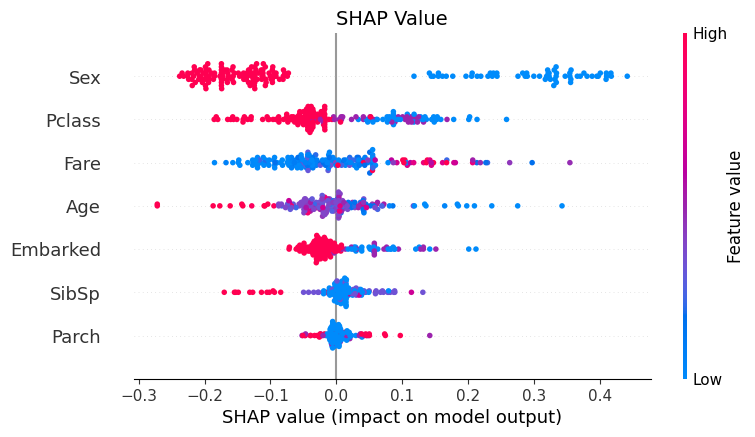

Stacking F1: 0.765625


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성



In [ ]:
# 1. 라이브러리와 데이터 준비
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import shap
from pycaret.classification import compare_models, pull, setup
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

df = pd.read_csv('Bank Customer Churn Prediction.csv')
df = df.drop(columns=['customer_id'], errors='ignore')

le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

X = df.drop(columns='churn')
y = df['churn']

# customer_id는 고객 식별용 번호라 churn 패턴 학습보다 식별 기능이 강해 제거했다.
# 범주형 변수는 baseline 흐름을 유지하기 위해 LabelEncoder로 간단히 수치화했다.

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
# churn 데이터는 한쪽으로 치우쳐 있을 가능성이 있어 train/valid를 나눌 때 stratify를 사용해클래스 비율이 비슷하게 유지되도록 했다. 


print(df.head())
print(df.shape)
print(df.isnull().sum())



   credit_score  country  gender  age  tenure    balance  products_number  \
0           619        0       0   42       2       0.00                1   
1           608        2       0   41       1   83807.86                1   
2           502        0       0   42       8  159660.80                3   
3           699        0       0   39       1       0.00                2   
4           850        2       0   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0          93826.63      0  
4            1              1          79084.10      0  
(10000, 11)
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_

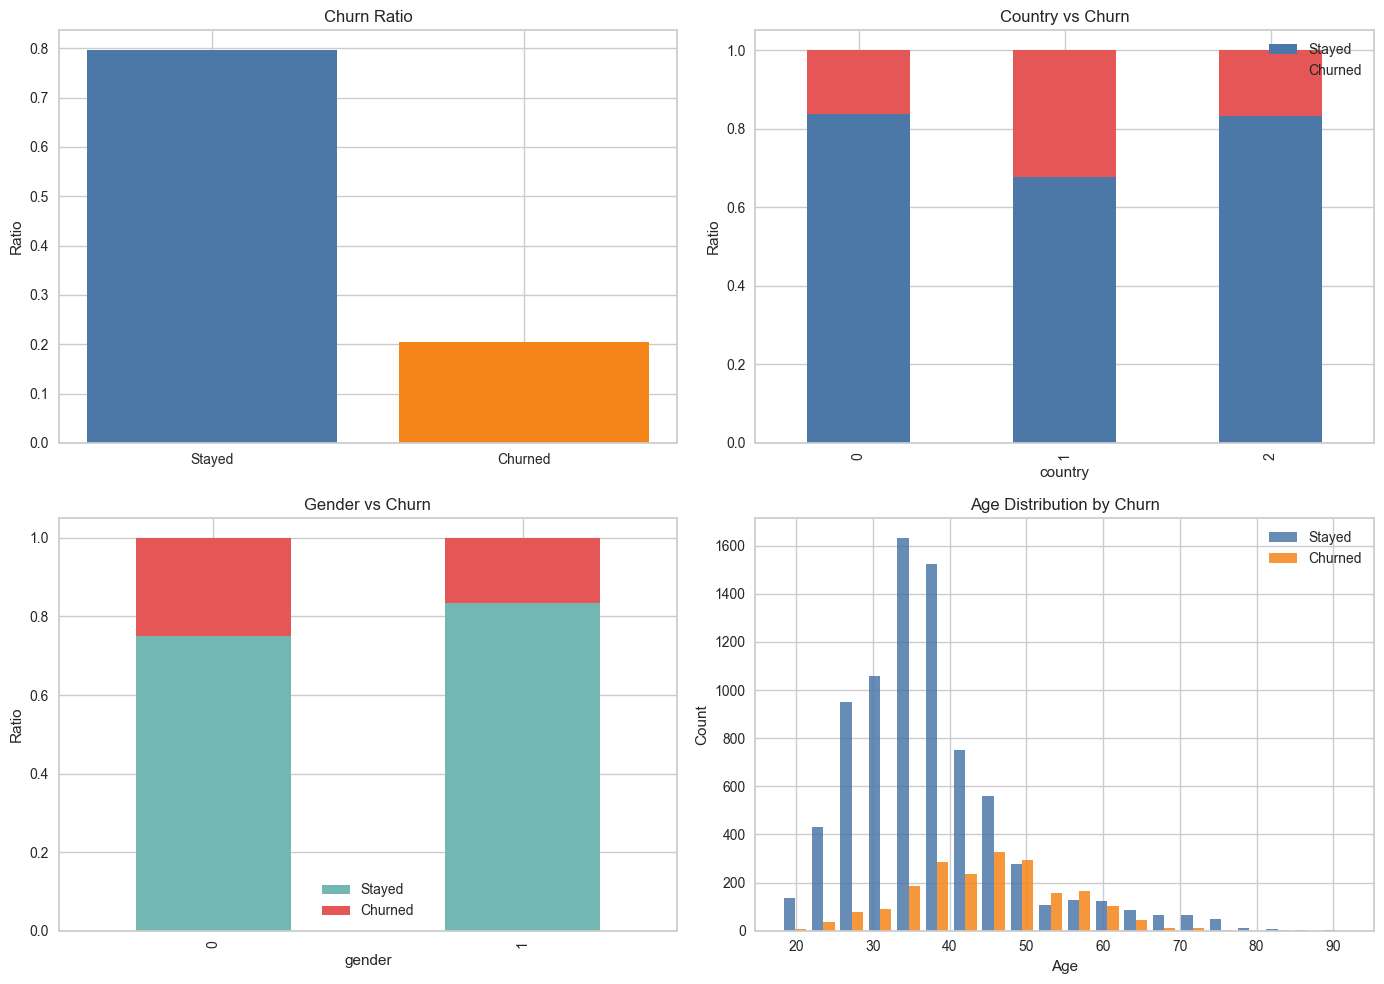

In [ ]:
# 2. EDA 그래프


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

churn_rate = df['churn'].value_counts(normalize=True).sort_index()
axes[0, 0].bar(['Stayed', 'Churned'], churn_rate.values, color=['#4C78A8', '#F58518'])
axes[0, 0].set_title('Churn Ratio')
axes[0, 0].set_ylabel('Ratio')

country_churn = pd.crosstab(df['country'], df['churn'], normalize='index')
country_churn.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#4C78A8', '#E45756'])
axes[0, 1].set_title('Country vs Churn')
axes[0, 1].set_ylabel('Ratio')
axes[0, 1].legend(['Stayed', 'Churned'])

gender_churn = pd.crosstab(df['gender'], df['churn'], normalize='index')
gender_churn.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#72B7B2', '#E45756'])
axes[1, 0].set_title('Gender vs Churn')
axes[1, 0].set_ylabel('Ratio')
axes[1, 0].legend(['Stayed', 'Churned'])

axes[1, 1].hist(
    [df.loc[df['churn'] == 0, 'age'], df.loc[df['churn'] == 1, 'age']],
    bins=20,
    label=['Stayed', 'Churned'],
    color=['#4C78A8', '#F58518'],
    alpha=0.85,
)
axes[1, 1].set_title('Age Distribution by Churn')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# EDA 해석:
# 전체 churn 비율은 클래스 비중 비교가 쉬운 막대그래프로 확인했고 이탈 고객 비중이 약 20%라 불균형 데이터로 보았다.
# country와 gender는 그룹별 stayed/churned 비율 비교가 중요해 누적 막대그래프를 사용했고
# 특정 국가(1번)) 그룹과 gender 0번 그룹에서 상대적으로 churn 비율이 더 높게 나타났다.
# age는 분포 차이를 보기 위해 히스토그램을 사용했으며 churn 고객이 40~50대에 더 많이 분포하는 경향을 확인했다.
# 따라서 country, gender, age는 churn 예측에 의미가 있을 가능성이 높은 변수라고 판단했다.



In [ ]:
# 3. Feature Selection + PyCaret으로 상위 모델 4개 확인

# RandomForest를 이용해 변수 중요도를 먼저 계산하고 트리 기반 모델의 importance를 활용해 어떤 변수가 churn 예측에 중요한지 확인했다. 
fs_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1,
)
fs_model.fit(X_train, y_train)

# 학습된 RandomForest 모델에서 feature importance를 추출해 데이터프레임으로 정리하고 중요도 순으로 정렬했다.
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': fs_model.feature_importances_,
}).sort_values('importance', ascending=False)

# 중요도가 높은 상위 7개 변수만 남겨 모델을 단순화하고 불필요한 변수 영향 줄일려고 하였다.
selected_features = importance_df.head(7)['feature'].tolist()
print(importance_df)
print('selected_features =', selected_features)

# 선택한 변수만 사용해 train/valid 데이터프레임을 새로 만들었다.
X_train_fs = X_train[selected_features].copy()
X_valid_fs = X_valid[selected_features].copy()

# PyCaret setup에 넣기 위해 train 데이터와 target을 다시 합쳤다.
train_fs_df = X_train_fs.copy()
train_fs_df['churn'] = y_train.values

# PyCaret 분류 환경을 설정하는 부분이다.
# stratifiedkfold를 사용해 불균형 데이터를 고려한 상태에서 모델 비교가 이루어지도록 했다.
clf = setup(
    data=train_fs_df,
    target='churn',
    session_id=RANDOM_STATE,
    fold_strategy='stratifiedkfold',
    fold=5,
    html=False,
    verbose=False,
)

# 여러 분류 모델을 같은 조건에서 비교해 F1 score 기준으로 상위 4개 모델을 선택했다.
pycaret_top4 = compare_models(sort='F1', n_select=4)

# 리더보드에서 모델별 주요 지표를 확인했다. F1 score를 중심으로 모델 성능을 비교했고, Accuracy, AUC, Recall, Precision도 함께 확안하였다.
pycaret_leaderboard = pull().copy()
print(pycaret_leaderboard[['Model', 'Accuracy', 'AUC', 'Recall', 'Prec.', 'F1']])


# Feature Selection과 모델 선정 기준:
# RandomForest importance를 기준으로 변수 영향을 확인했다.
# 결과에서 age가 가장 크게 나타났고, balance, estimated_salary, products_number, credit_score도비교적 높은 중요도를 보였다. 반면 gender와 credit_card는 중요도가 낮게 나타났다.
# 그래서 상위 7개 변수만 선택해 핵심 정보는 유지하고 불필요한 변수는 줄이도록 했다.
# 모델은 PyCaret으로 여러 알고리즘을 같은 조건에서 비교했다.
# churn 데이터는 불균형 구조라 accuracy보다 F1 score를 중심으로 성능을 확인했다.
# 그 결과 boosting 계열과 트리 기반 모델이 상위권에 위치했고,  선형 모델은 F1이 낮게 나타나 상대적으로 성능이 떨어지는 모습을 보였다.


            feature  importance
3               age    0.252922
5           balance    0.141386
9  estimated_salary    0.139946
6   products_number    0.136131
0      credit_score    0.134461
4            tenure    0.078743
1           country    0.040350
8     active_member    0.036553
2            gender    0.020729
7       credit_card    0.018779
selected_features = ['age', 'balance', 'estimated_salary', 'products_number', 'credit_score', 'tenure', 'country']


                                    Model  Accuracy     AUC  Recall   Prec.  \
gbc          Gradient Boosting Classifier    0.8480  0.8457  0.4339  0.7092   
catboost              CatBoost Classifier    0.8443  0.8460  0.4277  0.6901   
ada                  Ada Boost Classifier    0.8382  0.8303  0.4330  0.6567   
lightgbm  Light Gradient Boosting Machine    0.8384  0.8332  0.4312  0.6604   
xgboost         Extreme Gradient Boosting    0.8288  0.8222  0.4435  0.6120   
rf               Random Forest Classifier    0.8425  0.8306  0.4076  0.6946   
et                 Extra Trees Classifier    0.8396  0.8252  0.3883  0.6887   
dt               Decision Tree Classifier    0.7798  0.6638  0.4680  0.4606   
qda       Quadratic Discriminant Analysis    0.8038  0.7865  0.1665  0.5614   
lda          Linear Discriminant Analysis    0.7791  0.7400  0.0938  0.3446   
knn                K Neighbors Classifier    0.7643  0.5402  0.0894  0.2673   
nb                            Naive Bayes    0.7841 

                 model  cv_f1_mean  cv_f1_std  cv_accuracy_mean
0        random_forest    0.590615   0.025833          0.817875
1          extra_trees    0.581680   0.021511          0.792875
2              xgboost    0.552807   0.028632          0.850875
3  logistic_regression    0.472789   0.014749          0.700375
[Best Single Model]
model = random_forest
valid_f1 = 0.6049
valid_accuracy = 0.821
[Stacking Model]
valid_f1 = 0.5718
valid_accuracy = 0.854
[Classification Report - Stacking]
              precision    recall  f1-score   support

           0     0.8771    0.9498    0.9120      1593
           1     0.7091    0.4791    0.5718       407

    accuracy                         0.8540      2000
   macro avg     0.7931    0.7144    0.7419      2000
weighted avg     0.8429    0.8540    0.8428      2000



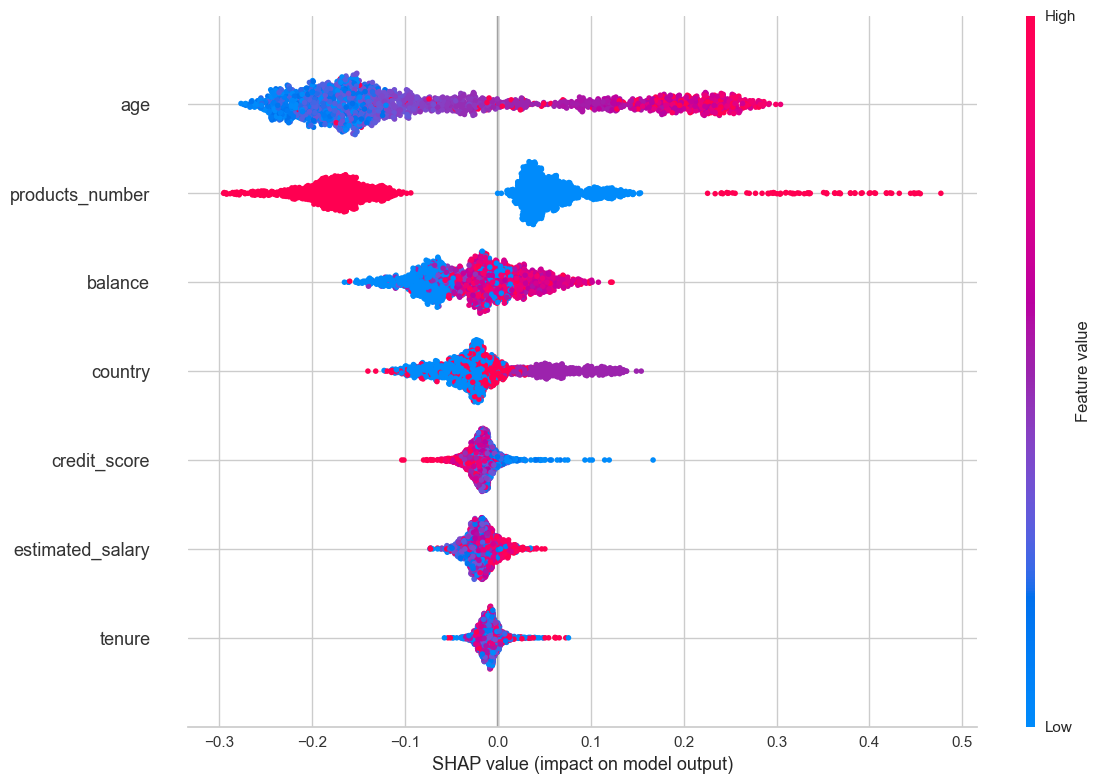

In [ ]:
# 4. Optuna 튜닝, Stacking, SHAP

# 후보 모델 목록을 한번에 보기 쉽게 정리한 부분
def build_candidates():
    return {
        'logistic_regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'random_forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'extra_trees': ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'xgboost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
    }

# LogisticRegression 의 하이퍼파라미터를 튜닝하는 함수. Optuna가 이 함수를 반복적으로 호출하면서 다양한 하이퍼파라미터 조합을 시도
# Trial 마다 다른 파리미터 조합을 적용해 학습하고 vaslidation set에서 예측한 후 F1 score를 반환한다. 
def objective_logistic(trial):
    model = LogisticRegression(
        C=trial.suggest_float('C', 0.01, 10.0, log=True),
        solver=trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_fs, y_train)
    pred = model.predict(X_valid_fs)
    return f1_score(y_valid, pred)

# RandomForest의 하이퍼파라미터를 조정하기 위한 목적 함수
# 트리 개수, 최대 깊이, leaf 조건을 바꿔가며 F1 score가 가장 잘 나오는 조합을 찾는다.
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 200, 600),
        max_depth=trial.suggest_int('max_depth', 4, 12),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_fs, y_train)
    pred = model.predict(X_valid_fs)
    return f1_score(y_valid, pred)

# ExtraTrees의 하이퍼파라미터를 조정하기 위한 목적 함수
def objective_et(trial):
    model = ExtraTreesClassifier(
        n_estimators=trial.suggest_int('n_estimators', 200, 600),
        max_depth=trial.suggest_int('max_depth', 4, 12),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train_fs, y_train)
    pred = model.predict(X_valid_fs)
    return f1_score(y_valid, pred)

# XGBoost의 하이퍼파라미터를 조정하기 위한 목적 함수
def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 200, 500),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.7, 1.0),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_fs, y_train)
    pred = model.predict(X_valid_fs)
    return f1_score(y_valid, pred)

# 각 모델 별로 Optuna로 최적의 하이퍼파라미터 탐색을 진행한다. direction='maximize'로 F1 score가 최대가 되는 방향으로 탐색하도록 설정했다.
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_logistic, n_trials=15)
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=15)
study_et = optuna.create_study(direction='maximize')
study_et.optimize(objective_et, n_trials=15)
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15)

# Optuna 에서 찾은 최적 파라미터를 이용해 최종 비교용 모델들을 다시 구성
tuned_models = {
    'logistic_regression': LogisticRegression(
        **study_lr.best_params,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    'random_forest': RandomForestClassifier(
        **study_rf.best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'extra_trees': ExtraTreesClassifier(
        **study_et.best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    'xgboost': XGBClassifier(
        **study_xgb.best_params,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
    ),
}

# 튜닝된 각 모델을 동일 조건에서 비교하기 위해 5-fold stratified CV를 수행,
# 모델마다 F1 score와 accuracy를 측정해 평균과 표준편차를 기록했다.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
score_rows = []
for name, model in tuned_models.items():
    f1_scores = cross_val_score(model, X_train_fs, y_train, cv=cv, scoring='f1', n_jobs=-1)
    acc_scores = cross_val_score(model, X_train_fs, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    score_rows.append({
        'model': name,
        'cv_f1_mean': f1_scores.mean(),
        'cv_f1_std': f1_scores.std(),
        'cv_accuracy_mean': acc_scores.mean(),
    })

score_df = pd.DataFrame(score_rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print(score_df)

# 교차검증 결과에서 F1 score가 가장 높은 모델을 best_model로 선정해 validation set에서 최종 성능을 확인했다.
best_model_name = score_df.loc[0, 'model']
best_model = clone(tuned_models[best_model_name])
best_model.fit(X_train_fs, y_train)
valid_pred = best_model.predict(X_valid_fs)

best_f1 = f1_score(y_valid, valid_pred)
best_acc = accuracy_score(y_valid, valid_pred)

# 여러 모델의 장점을 활용하기 위해 Stacking 모델을 구성했다. 
# 1차 모델로는 Optuna로 튜닝된 4개 모델을 그대로 사용했고, 최종 예측을 담당하는 후방 모델로는 LogisticRegression을 선택했다.
stacking_model = StackingClassifier(
    estimators=[
        ('lr', clone(tuned_models['logistic_regression'])),
        ('rf', clone(tuned_models['random_forest'])),
        ('et', clone(tuned_models['extra_trees'])),
        ('xgb', clone(tuned_models['xgboost'])),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    n_jobs=-1,
)
stacking_model.fit(X_train_fs, y_train)
stacking_pred = stacking_model.predict(X_valid_fs)

stacking_f1 = f1_score(y_valid, stacking_pred)
stacking_acc = accuracy_score(y_valid, stacking_pred)

# 최종 결과 출력
# 어떤 모델이 실제 hold-out 데이터에서 더 좋은 성능을 보이는지 F1 score와 accuracy를 중심으로 비교했다.
print('[Best Single Model]')
print('model =', best_model_name)
print('valid_f1 =', round(best_f1, 4))
print('valid_accuracy =', round(best_acc, 4))

print('[Stacking Model]')
print('valid_f1 =', round(stacking_f1, 4))
print('valid_accuracy =', round(stacking_acc, 4))
print('[Classification Report - Stacking]')
print(classification_report(y_valid, stacking_pred, digits=4))

# shap 분석을 위해 트리 기반 모델이 최종 기준 모델로 선정된 경우 해당 모델을 사용하고, 그렇지 않으면 random_forest를 사용해 SHAP 분석을 진행했다.
shap_model_name = best_model_name if best_model_name in {'random_forest', 'extra_trees', 'xgboost'} else 'random_forest'
shap_model = best_model if shap_model_name == best_model_name else clone(tuned_models['random_forest'])

if shap_model_name != best_model_name:
    shap_model.fit(X_train_fs, y_train)

# 선택한 트리 기반 모델에 대해 shap 값을 계산하고 시각화
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_valid_fs)

if isinstance(shap_values, list):
    plot_values = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    plot_values = shap_values[:, :, 1]
else:
    plot_values = shap_values

shap.summary_plot(
    plot_values,
    X_valid_fs,
    plot_type="dot",
    plot_size=(12, 8),
    show=True
)

# SHAP 사후분석과 인사이트:
# 최종 비교에서 선택된 트리 기반 기준 모델에 대해 SHAP summary plot으로 변수별 예측 기여도를 분석한 결과,
# age와 products_number가 이탈 예측에 가장 큰 영향을 미치는 변수로 나타났다.
# age는 값이 높을수록 SHAP 값이 양의 방향으로 이동해 이탈 확률을 높이는 경향이 확인되었고
# products_number는 단순히 많고 적음의 문제가 아니라 특정 구간에서 이탈 위험이 커지는 비선형 패턴을 보였다.
# 또한 balance도 이탈 확률 증가에 일정 부분 기여했으며, country와 credit_score는 보조적인 영향을 미쳤다.
# 반면 estimated_salary와 tenure의 영향은 상대적으로 작게 나타났다.
# 따라서 고연령 고객, 상품 수 패턴이 특이한 고객, 잔고가 높은 고객군을 중심으로 맞춤형 유지 전략을 우선 적용하는 것이 효과적인 이탈 방지 방안이라고 판단했다.

# validation score 출력 및 해석:
# validation score는 학습에 사용하지 않은 hold-out validation set에서 모델의 일반화 성능을 확인하기 위해 출력하였다.
# best single model인 random_forest는 valid_f1=0.6049, valid_accuracy=0.821로 나타났고
# stacking model은 valid_accuracy=0.854로 더 높았지만 valid_f1=0.5718로 더 낮았다.
# 이는 클래스 불균형 상황에서 accuracy가 높아도 실제 이탈 고객을 충분히 탐지하지 못할 수 있음을 보여준다.
# 따라서 accuracy보다 F1 score를 중심으로 모델을 평가하는 것이 더 적절하며, 최종적으로는 random_forest 모델이 더 우수하다고 판단하였다.


